# Linear RGB and OkLab gradients

This example compares two gradients with identical blue and yellow endpoints. One interpolates linear-light sRGB channels; the other converts the endpoints to OkLab and interpolates its perceptual `L`, `a`, and `b` components.

In [1]:
from pathlib import Path

import brushcue
from IPython.display import Image, Markdown, display

WIDTH = 600
HEIGHT = 180
OUTPUT_DIRECTORY = Path("/home/dito/dev/monorepo/writing/graphics/chapters/color-formats/assets")
INTERPOLATIONS = (
    ("Linear RGB", 0, "linear-rgb-gradient.png"),
    ("OkLab", 1, "oklab-gradient.png"),
)

ctx = brushcue.Context()

[wgpu] using backend Vulkan — adapter 'NVIDIA GeForce RTX 5070' (DiscreteGpu), driver 'NVIDIA'


In [2]:
FREEFORM_BODY = """
let t = canvas_position.x / 600.0;
let blue_srgb = vec3<f32>(0.08, 0.24, 0.92);
let yellow_srgb = vec3<f32>(0.98, 0.84, 0.08);
let blue_linear = srgb_to_linear(blue_srgb);
let yellow_linear = srgb_to_linear(yellow_srgb);

if interpolation_mode == 0 {
    return vec4<f32>(linear_to_srgb(mix(blue_linear, yellow_linear, t)), 1.0);
}

let blue_oklab = linear_srgb_to_oklab(blue_linear);
let yellow_oklab = linear_srgb_to_oklab(yellow_linear);
let rgb = linear_to_srgb(oklab_to_linear_srgb(mix(blue_oklab, yellow_oklab, t)));
return vec4<f32>(rgb, 1.0);
"""

WGSL_HELPERS = """
fn srgb_to_linear(rgb: vec3<f32>) -> vec3<f32> {
    let lo = rgb / 12.92;
    let hi = pow((rgb + 0.055) / 1.055, vec3<f32>(2.4));
    return select(hi, lo, rgb <= vec3<f32>(0.04045));
}

fn linear_to_srgb(rgb: vec3<f32>) -> vec3<f32> {
    let lo = 12.92 * rgb;
    let hi = 1.055 * pow(max(rgb, vec3<f32>(0.0)), vec3<f32>(1.0 / 2.4)) - 0.055;
    return select(hi, lo, rgb <= vec3<f32>(0.0031308));
}

fn linear_srgb_to_oklab(rgb: vec3<f32>) -> vec3<f32> {
    let l = pow(0.4122214708 * rgb.r + 0.5363325363 * rgb.g + 0.0514459929 * rgb.b, 1.0 / 3.0);
    let m = pow(0.2119034982 * rgb.r + 0.6806995451 * rgb.g + 0.1073969566 * rgb.b, 1.0 / 3.0);
    let s = pow(0.0883024619 * rgb.r + 0.2817188376 * rgb.g + 0.6299787005 * rgb.b, 1.0 / 3.0);
    return vec3<f32>(
        0.2104542553 * l + 0.7936177850 * m - 0.0040720468 * s,
        1.9779984951 * l - 2.4285922050 * m + 0.4505937099 * s,
        0.0259040371 * l + 0.7827717662 * m - 0.8086757660 * s,
    );
}

fn oklab_to_linear_srgb(oklab: vec3<f32>) -> vec3<f32> {
    let l = pow(oklab.x + 0.3963377774 * oklab.y + 0.2158037573 * oklab.z, 3.0);
    let m = pow(oklab.x - 0.1055613458 * oklab.y - 0.0638541728 * oklab.z, 3.0);
    let s = pow(oklab.x - 0.0894841775 * oklab.y - 1.2914855480 * oklab.z, 3.0);
    return vec3<f32>(
        4.0767416621 * l - 3.3077115913 * m + 0.2309699292 * s,
        -1.2684380046 * l + 2.6097574011 * m - 0.3413193965 * s,
        -0.0041960863 * l - 0.7034186147 * m + 1.7076147010 * s,
    );
}
"""

## Linear RGB

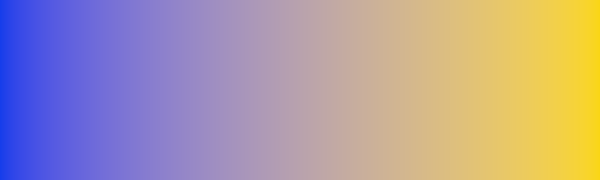

## OkLab

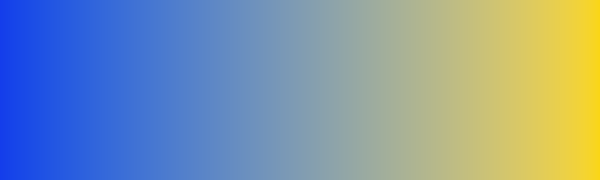

In [3]:
for label, interpolation_mode, filename in INTERPOLATIONS:
    gradient = brushcue.Composition.freeform_shader(
        FREEFORM_BODY,
        WGSL_HELPERS,
        brushcue.Bounds2f.from_x_y_width_height(0, 0, WIDTH, HEIGHT),
        brushcue.ColorRepresentation.srgb(),
        brushcue.Dictionary.create().add("interpolation_mode", interpolation_mode),
    )
    png = gradient.execute(ctx).to_image_bytes(ctx)
    (OUTPUT_DIRECTORY / filename).write_bytes(png)
    display(Markdown(f"## {label}"))
    display(Image(data=png))

Linear RGB interpolation mixes physical light values, so the middle of this complementary-color blend becomes noticeably desaturated. OkLab follows a path through perceptual lightness and opponent color components, producing a more even transition through the middle.